# Architecture 1 — Direct Multi-Step XGBoost / HistGradientBoosting

## Executive Summary
**Objective:** Train 24 separate (direct multi-step) gradient boosting models — one per forecast horizon h=1..24 — using Optuna-tuned hyperparameters and time-series cross-validation.

**Expected results:** MAE ≈ 1.1–1.3 at h=1, degrading to ≈ 4.2–4.6 at h=24.

**Critical rules:**
- Target: `y = PM25.shift(-h)` — always shift the target, never shift features forward.
- CV: `TimeSeriesSplit` only — no KFold.
- Log transform: all models wrapped in `TransformedTargetRegressor(log1p, expm1)`.

In [5]:
import sys
sys.path.insert(0, '..')

import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.notebook import tqdm

from src.config import (
    DATA_PATH, TARGET, HORIZONS, N_OPTUNA_TRIALS,
    MODEL_DIR, FIGURES_DIR, RESULTS_DIR
)
from src.data_loader import load_data, train_test_split
from src.feature_engineering import build_feature_matrix
from src.models.baseline_gbm import train_direct_multistep, predict_all_horizons, load_models
from src.evaluation import compute_metrics, plot_horizon_metrics, plot_actual_vs_predicted, shap_analysis, comparison_table
from src.utils import ensure_dirs, set_seed

set_seed(42)
ensure_dirs(MODEL_DIR, FIGURES_DIR, RESULTS_DIR)
sns.set_theme(style='whitegrid', palette='tab10')
print('Setup complete')

Setup complete


## 1. Load and Split Data

In [6]:
df = load_data(DATA_PATH)
train_df, test_df = train_test_split(df)
print(f'Train: {len(train_df):,} rows | Test: {len(test_df):,} rows')

13:10:58 | src.data_loader | INFO | Loading data from D:\MOJE\DATA_SCIENCE\ML_WARSAW_AQI_TOY\warsaw_aq_forecast\data\raw\FINAL_merged_PM25_1g_all_seasons.csv
13:10:58 | src.data_loader | INFO | Missing values per column:
MzOtwoBrzozo    1084
MzWarWokalna    2028
MzWarAlNiepo     575
MzLegZegrzyn    1511
MzPiasPulask    1002
MzWarChrosci     416
MzWarBajkowa     636
dir_48            48
dir_24            48
13:10:58 | src.data_loader | INFO | Loaded 52608 rows, 27 columns, range 2019-01-01 00:00:00 → 2024-12-31 23:00:00
13:10:58 | src.data_loader | INFO | Train: 43824 rows (2019-01-01 00:00:00 → 2023-12-31 23:00:00)
13:10:58 | src.data_loader | INFO | Test : 8784 rows (2024-01-01 00:00:00 → 2024-12-31 23:00:00)


Train: 43,824 rows | Test: 8,784 rows


## 2. Feature Matrix Preview (h=24)
Verify that no raw station columns appear in X.

In [7]:
X_preview, y_preview = build_feature_matrix(train_df, horizon=24)
print(f'Feature matrix shape: {X_preview.shape}')
print(f'Feature names ({len(X_preview.columns)}):')
for i, col in enumerate(X_preview.columns):
    print(f'  {i:2d}. {col}')

13:10:58 | src.feature_engineering | INFO | One-hot encoded HYSPLIT categoricals: ['dir_48', 'dir_24'] → 8 dummy cols
13:10:58 | src.feature_engineering | INFO | Retaining 10 HYSPLIT numeric columns
13:10:58 | src.feature_engineering | INFO | horizon=24 | X: (38057, 45) | y mean=17.38, y std=12.67


Feature matrix shape: (38057, 45)
Feature names (45):
   0. TEMP
   1. WIND_SPEED
   2. PRESS_SEA
   3. HUMIDITY
   4. DEW_POINT
   5. RAIN_6H
   6. SUNSHINE
   7. blh
   8. lon_48
   9. lat_48
  10. dist_48_straight
  11. dist_48_total
  12. ratio_48
  13. lon_24
  14. lat_24
  15. dist_24_straight
  16. dist_24_total
  17. ratio_24
  18. hour_sin
  19. hour_cos
  20. month_sin
  21. month_cos
  22. day_sin
  23. day_cos
  24. is_weekend
  25. pm25_now
  26. pm25_lag_24h
  27. pm25_lag_48h
  28. rolling_mean_24h
  29. rolling_max_24h
  30. trend_24h
  31. MzOtwoBrzozo_lag1h
  32. MzWarWokalna_lag1h
  33. MzWarAlNiepo_lag1h
  34. MzLegZegrzyn_lag1h
  35. MzPiasPulask_lag1h
  36. MzWarBajkowa_lag1h
  37. dir_48_L
  38. dir_48_N
  39. dir_48_S
  40. dir_48_W
  41. dir_24_L
  42. dir_24_N
  43. dir_24_S
  44. dir_24_W


## 3. Train XGBoost — All 24 Horizons
This cell trains 24 models with Optuna tuning. Each horizon takes ~2–5 minutes with n_trials=50.
Reduce `N_OPTUNA_TRIALS` for a quick test run.

In [8]:
# Set N_OPTUNA_TRIALS=5 for a quick smoke test; use 50 for full training
QUICK_TEST = True
n_trials = 5 if QUICK_TEST else N_OPTUNA_TRIALS

print(f'Training XGBoost with n_trials={n_trials} per horizon...')
xgb_models = train_direct_multistep(
    train_df, model_type='xgb', n_trials=n_trials, save_models=True
)
print('XGBoost training complete.')

13:10:58 | src.models.baseline_gbm | INFO | ============================================================
13:10:58 | src.models.baseline_gbm | INFO | Direct multi-step training: XGB | 24 horizons | 5 Optuna trials each
13:10:58 | src.models.baseline_gbm | INFO | ============================================================
13:10:58 | src.models.baseline_gbm | INFO | [1/24] Starting horizon h=1 ...


Training XGBoost with n_trials=5 per horizon...


13:10:59 | src.feature_engineering | INFO | One-hot encoded HYSPLIT categoricals: ['dir_48', 'dir_24'] → 8 dummy cols
13:10:59 | src.feature_engineering | INFO | Retaining 10 HYSPLIT numeric columns
13:10:59 | src.feature_engineering | INFO | horizon=1 | X: (38271, 45) | y mean=17.38, y std=12.69
13:10:59 | src.models.baseline_gbm | INFO |   X=(38271, 45)  y_mean=17.38  y_std=12.69
13:10:59 | src.models.baseline_gbm | INFO |   Optuna search: XGB | horizon=+1h | 5 trials | 5-fold TimeSeriesSplit
13:11:22 | src.models.baseline_gbm | INFO |   trial 1/5 — best CV MAE so far: 1.8921
13:11:35 | src.models.baseline_gbm | INFO |   trial 2/5 — best CV MAE so far: 1.8921
13:11:39 | src.models.baseline_gbm | INFO |   trial 3/5 — best CV MAE so far: 1.8921
13:11:44 | src.models.baseline_gbm | INFO |   trial 4/5 — best CV MAE so far: 1.8921
13:11:48 | src.models.baseline_gbm | INFO |   trial 5/5 — best CV MAE so far: 1.8369
13:11:48 | src.models.baseline_gbm | INFO |   Best h=1: CV MAE=1.8369 in 49

XGBoost training complete.


## 4. Train HistGradientBoosting — All 24 Horizons

In [9]:
print(f'Training HGB with n_trials={n_trials} per horizon...')
hgb_models = train_direct_multistep(
    train_df, model_type='hgb', n_trials=n_trials, save_models=True
)
print('HGB training complete.')

13:31:31 | src.models.baseline_gbm | INFO | ============================================================
13:31:31 | src.models.baseline_gbm | INFO | Direct multi-step training: HGB | 24 horizons | 5 Optuna trials each
13:31:31 | src.models.baseline_gbm | INFO | ============================================================
13:31:31 | src.models.baseline_gbm | INFO | [1/24] Starting horizon h=1 ...
13:31:31 | src.feature_engineering | INFO | One-hot encoded HYSPLIT categoricals: ['dir_48', 'dir_24'] → 8 dummy cols
13:31:31 | src.feature_engineering | INFO | Retaining 10 HYSPLIT numeric columns
13:31:31 | src.feature_engineering | INFO | horizon=1 | X: (38271, 45) | y mean=17.38, y std=12.69
13:31:31 | src.models.baseline_gbm | INFO |   X=(38271, 45)  y_mean=17.38  y_std=12.69
13:31:31 | src.models.baseline_gbm | INFO |   Optuna search: HGB | horizon=+1h | 5 trials | 5-fold TimeSeriesSplit


Training HGB with n_trials=5 per horizon...


13:31:55 | src.models.baseline_gbm | INFO |   trial 1/5 — best CV MAE so far: 1.8869
13:32:28 | src.models.baseline_gbm | INFO |   trial 2/5 — best CV MAE so far: 1.8291
13:32:30 | src.models.baseline_gbm | INFO |   trial 3/5 — best CV MAE so far: 1.8291
13:32:40 | src.models.baseline_gbm | INFO |   trial 4/5 — best CV MAE so far: 1.8291
13:32:48 | src.models.baseline_gbm | INFO |   trial 5/5 — best CV MAE so far: 1.8291
13:32:48 | src.models.baseline_gbm | INFO |   Best h=1: CV MAE=1.8291 in 77s | params={'learning_rate': 0.006194745024628934, 'max_iter': 880, 'max_depth': 6, 'min_samples_leaf': 37, 'l2_regularization': 0.020584494295802447, 'max_bins': 250}
13:32:56 | src.models.baseline_gbm | INFO | [1/24] h=1 done in 85s | elapsed=85s | ETA ~1961s
13:32:57 | src.models.baseline_gbm | INFO |   Saved → D:\MOJE\DATA_SCIENCE\ML_WARSAW_AQI_TOY\warsaw_aq_forecast\outputs\models\hgb_h1.pkl
13:32:57 | src.models.baseline_gbm | INFO | [2/24] Starting horizon h=2 ...
13:32:57 | src.feature_e

HGB training complete.


## 5. Evaluate on Test Set (2024)

In [10]:
results = {'XGBoost': {}, 'HGB': {}}

for h in tqdm(HORIZONS, desc='Evaluating horizons'):
    X_test_h, y_test_h = build_feature_matrix(test_df, horizon=h)

    xgb_pred = xgb_models[h].predict(X_test_h.values)
    hgb_pred = hgb_models[h].predict(X_test_h.values)

    results['XGBoost'][h] = compute_metrics(y_test_h.values, xgb_pred)
    results['HGB'][h] = compute_metrics(y_test_h.values, hgb_pred)

print('Evaluation complete.')

# Show h=1, 6, 12, 24 summary
for model_name in results:
    print(f'\n{model_name}:')
    for h in [1, 6, 12, 24]:
        m = results[model_name][h]
        print(f'  h={h:2d}: MAE={m["MAE"]:.3f}  RMSE={m["RMSE"]:.3f}  R²={m["R2"]:.3f}')

Evaluating horizons:   0%|          | 0/24 [00:00<?, ?it/s]

14:07:37 | src.feature_engineering | INFO | One-hot encoded HYSPLIT categoricals: ['dir_48', 'dir_24'] → 8 dummy cols
14:07:37 | src.feature_engineering | INFO | Retaining 10 HYSPLIT numeric columns
14:07:37 | src.feature_engineering | INFO | horizon=1 | X: (7802, 45) | y mean=12.62, y std=8.41
14:07:37 | src.feature_engineering | INFO | One-hot encoded HYSPLIT categoricals: ['dir_48', 'dir_24'] → 8 dummy cols
14:07:37 | src.feature_engineering | INFO | Retaining 10 HYSPLIT numeric columns
14:07:37 | src.feature_engineering | INFO | horizon=2 | X: (7800, 45) | y mean=12.62, y std=8.41
14:07:37 | src.feature_engineering | INFO | One-hot encoded HYSPLIT categoricals: ['dir_48', 'dir_24'] → 8 dummy cols
14:07:37 | src.feature_engineering | INFO | Retaining 10 HYSPLIT numeric columns
14:07:37 | src.feature_engineering | INFO | horizon=3 | X: (7798, 45) | y mean=12.62, y std=8.40
14:07:38 | src.feature_engineering | INFO | One-hot encoded HYSPLIT categoricals: ['dir_48', 'dir_24'] → 8 dummy

Evaluation complete.

XGBoost:
  h= 1: MAE=1.143  RMSE=1.849  R²=0.952
  h= 6: MAE=3.179  RMSE=4.591  R²=0.700
  h=12: MAE=4.138  RMSE=5.841  R²=0.513
  h=24: MAE=4.515  RMSE=6.267  R²=0.442

HGB:
  h= 1: MAE=1.135  RMSE=1.843  R²=0.952
  h= 6: MAE=3.147  RMSE=4.580  R²=0.701
  h=12: MAE=4.068  RMSE=5.709  R²=0.535
  h=24: MAE=4.499  RMSE=6.227  R²=0.449


## 6. MAE vs Horizon Plot

14:07:43 | src.evaluation | INFO | Saved figure: D:\MOJE\DATA_SCIENCE\ML_WARSAW_AQI_TOY\warsaw_aq_forecast\outputs\figures\arch1_mae_horizon.png


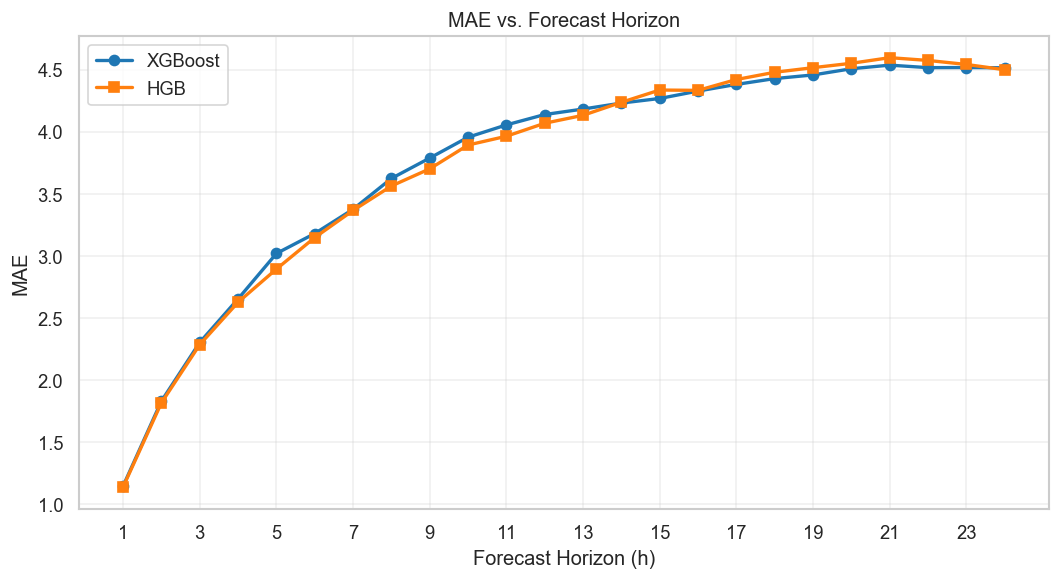

14:07:44 | src.evaluation | INFO | Saved figure: D:\MOJE\DATA_SCIENCE\ML_WARSAW_AQI_TOY\warsaw_aq_forecast\outputs\figures\arch1_r2_horizon.png


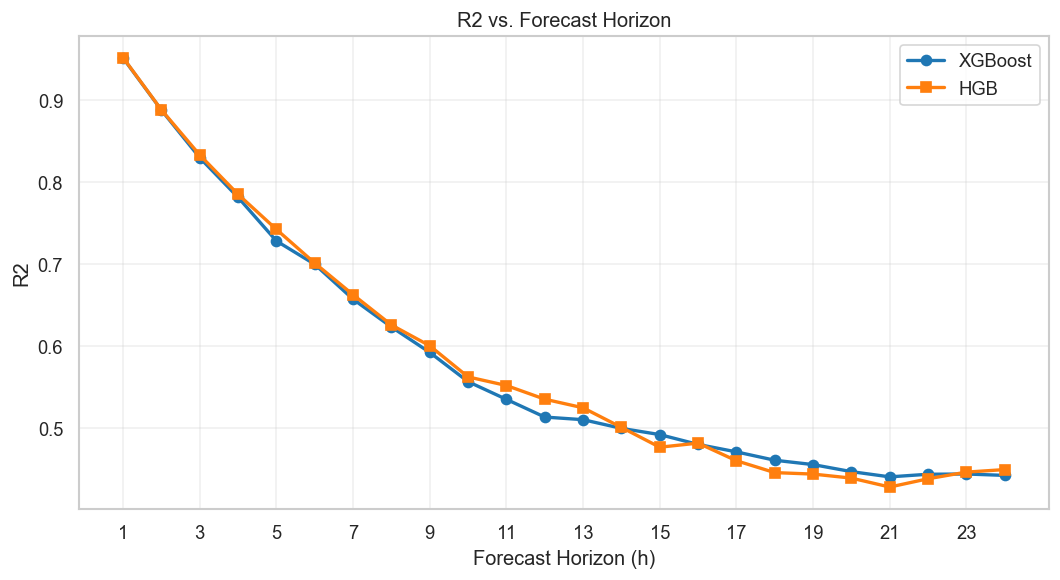

In [11]:
fig = plot_horizon_metrics(results, metric='MAE',
                           save_path=FIGURES_DIR / 'arch1_mae_horizon.png')
plt.show()

fig = plot_horizon_metrics(results, metric='R2',
                           save_path=FIGURES_DIR / 'arch1_r2_horizon.png')
plt.show()

## 7. Actual vs Predicted Time Series (h=24, Winter 2024 zoom)

14:07:44 | src.feature_engineering | INFO | One-hot encoded HYSPLIT categoricals: ['dir_48', 'dir_24'] → 8 dummy cols
14:07:44 | src.feature_engineering | INFO | Retaining 10 HYSPLIT numeric columns
14:07:44 | src.feature_engineering | INFO | horizon=24 | X: (7766, 45) | y mean=12.60, y std=8.39


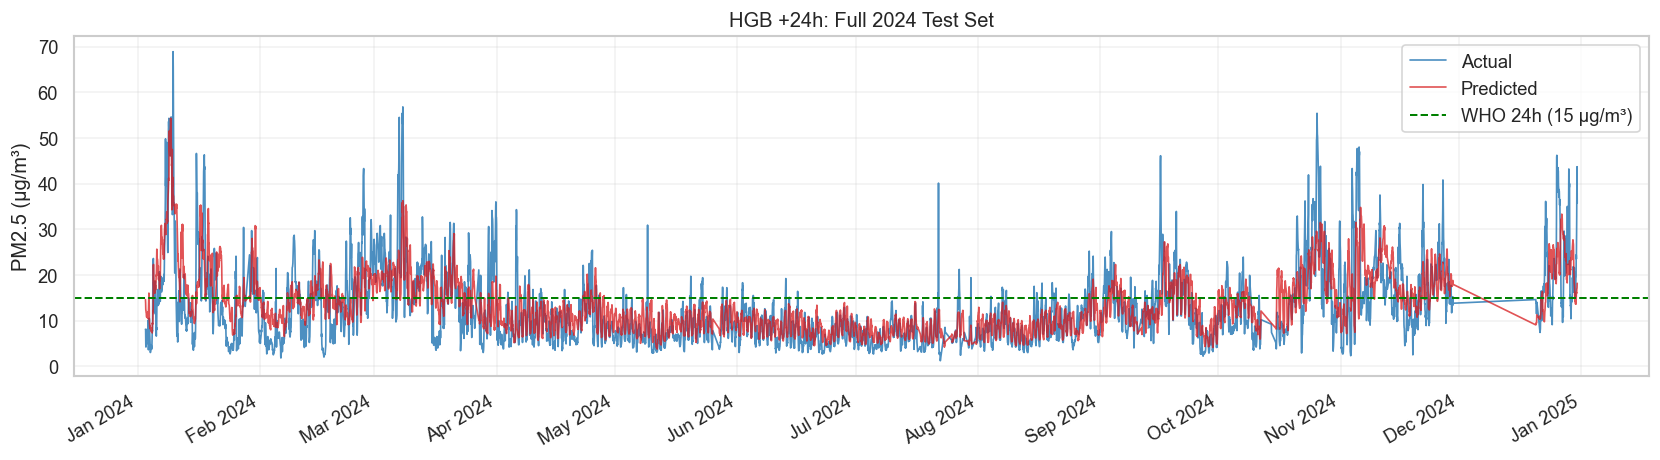

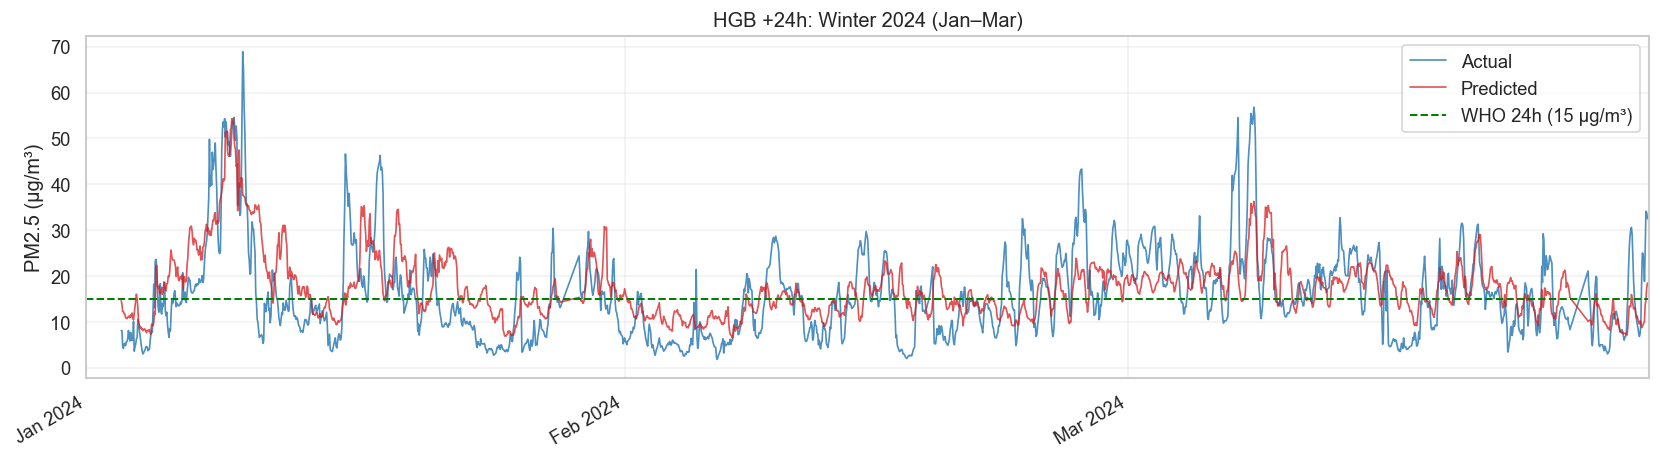

In [12]:
X_test_24, y_test_24 = build_feature_matrix(test_df, horizon=24)
hgb_pred_24 = hgb_models[24].predict(X_test_24.values)

fig = plot_actual_vs_predicted(
    y_test_24, hgb_pred_24,
    title='HGB +24h: Full 2024 Test Set',
    save_path=FIGURES_DIR / 'arch1_hgb_full_2024.png'
)
plt.show()

fig = plot_actual_vs_predicted(
    y_test_24, hgb_pred_24,
    title='HGB +24h: Winter 2024 (Jan–Mar)',
    zoom_period=('2024-01-01', '2024-03-31'),
    save_path=FIGURES_DIR / 'arch1_hgb_winter2024.png'
)
plt.show()

## 8. SHAP Feature Importance

In [13]:
for h in [1, 6, 12, 24]:
    X_test_h, _ = build_feature_matrix(test_df, horizon=h)
    # Unwrap TransformedTargetRegressor to get the underlying tree model
    inner_model = xgb_models[h].regressor_
    shap_analysis(
        inner_model, X_test_h, X_test_h.columns.tolist(),
        save_dir=FIGURES_DIR,
        title_suffix=f'XGB_h{h}'
    )

14:07:45 | src.feature_engineering | INFO | One-hot encoded HYSPLIT categoricals: ['dir_48', 'dir_24'] → 8 dummy cols
14:07:45 | src.feature_engineering | INFO | Retaining 10 HYSPLIT numeric columns
14:07:45 | src.feature_engineering | INFO | horizon=1 | X: (7802, 45) | y mean=12.62, y std=8.41
14:07:50 | src.evaluation | INFO | SHAP plots saved to D:\MOJE\DATA_SCIENCE\ML_WARSAW_AQI_TOY\warsaw_aq_forecast\outputs\figures
14:07:50 | src.feature_engineering | INFO | One-hot encoded HYSPLIT categoricals: ['dir_48', 'dir_24'] → 8 dummy cols
14:07:50 | src.feature_engineering | INFO | Retaining 10 HYSPLIT numeric columns
14:07:50 | src.feature_engineering | INFO | horizon=6 | X: (7792, 45) | y mean=12.61, y std=8.38
14:07:52 | src.evaluation | INFO | SHAP plots saved to D:\MOJE\DATA_SCIENCE\ML_WARSAW_AQI_TOY\warsaw_aq_forecast\outputs\figures
14:07:52 | src.feature_engineering | INFO | One-hot encoded HYSPLIT categoricals: ['dir_48', 'dir_24'] → 8 dummy cols
14:07:52 | src.feature_engineeri

## 9. Save Results

In [14]:
rows = []
for model_name, h_metrics in results.items():
    for h, metrics in h_metrics.items():
        rows.append({'Model': f'Arch1_{model_name}', 'Horizon': h, **metrics})

arch1_df = pd.DataFrame(rows)
arch1_df.to_csv(RESULTS_DIR / 'arch1_metrics.csv', index=False)
print('Saved arch1_metrics.csv')

# Print LaTeX-ready table for key horizons
tbl = comparison_table({'XGBoost': results['XGBoost'], 'HGB': results['HGB']})
print('\nKey horizon comparison:')
print(tbl.to_string(float_format='%.3f'))

Saved arch1_metrics.csv

Key horizon comparison:
                  MAE  RMSE    R2   MBE    IA
Model   Horizon                              
HGB     1       1.135 1.843 0.952 0.055 0.988
        6       3.147 4.580 0.701 0.655 0.911
        12      4.068 5.709 0.535 1.040 0.846
        24      4.499 6.227 0.449 0.853 0.798
XGBoost 1       1.143 1.849 0.952 0.055 0.988
        6       3.179 4.591 0.700 0.670 0.912
        12      4.138 5.841 0.513 1.199 0.843
        24      4.515 6.267 0.442 0.615 0.776
